# High-Frequency Data and Limit Order Books
## Lab 2

By: Imad AMRI, Nessrine CHIBA, Adonis JAMAL

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
trades = np.array([[pd.read_csv(f"Data/stock{i}_day{j}_trades.csv.gz") for i in range(0, 3)] for j in range(0, 5)], dtype=object)
trades_df = pd.concat([df.assign(stock=i, day=j) for (j, i), df in np.ndenumerate(trades)], ignore_index=True)

updates = np.array([[pd.read_csv(f"Data/stock{i}_day{j}_updates.csv.gz") for i in range(0, 3)] for j in range(0, 5)], dtype=object)
updates_df = pd.concat([df_updates.assign(stock=i, day=j) for (j, i), df_updates in np.ndenumerate(updates)], ignore_index=True)

---
## 1. Non-homogeneous Poisson process and trade times

### 1.1 Thinning algorithm

In [3]:
def thinning_algorithm(T, mu, lambda_star):
    """
    Thinning algorithm for the simulation of a non-homogeneous Poisson process on [0, T] with a given intensity μ : [0, T] → R+.

    Args:
        T (float): ts horizon.
        mu (callable): intensity function.
        lambda_star (float): constant upper bound.
    """
    t = 0
    points = []
    while t < T:
        t += np.random.exponential(1 / lambda_star)
        if t >= T: break
        if np.random.uniform(0, 1) < mu(t) / lambda_star:
            points.append(t)

    return np.array(points)

In [4]:
T_sim = 10.0
mu_deterministic = lambda t: 5 * (1 + np.sin(t))
lambda_max = 10.0

n_simulations = 3000
all_points = []
for _ in range(n_simulations):
    points = thinning_algorithm(T_sim, mu_deterministic, lambda_max)
    all_points.extend(points)

all_points = np.array(all_points)

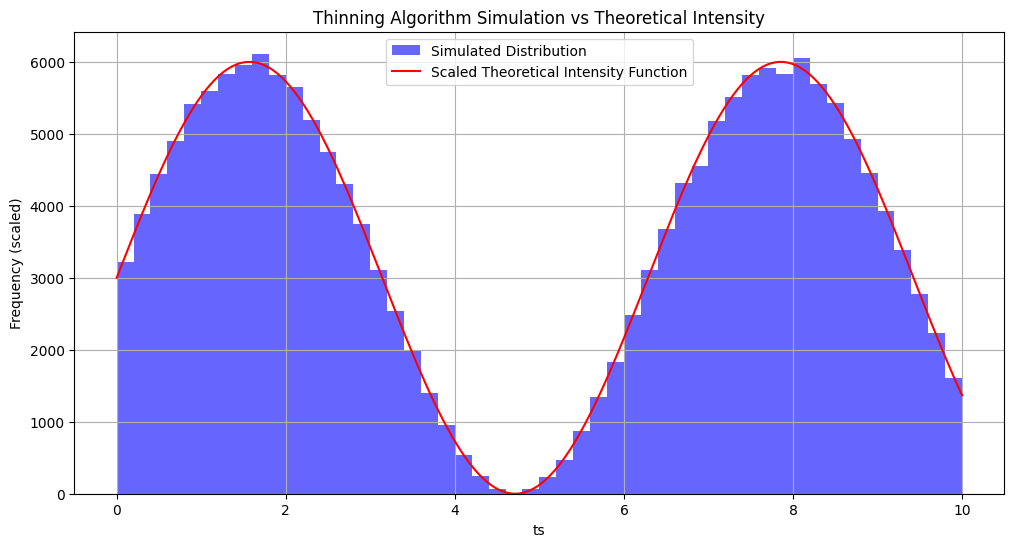

In [5]:
plt.figure(figsize=(12, 6))
count, bins, ignored = plt.hist(all_points, bins=50, density=False, alpha=0.6, color='b', label='Simulated Distribution')

bin_width = bins[1] - bins[0]
scaling_factor = n_simulations * bin_width

t_vals = np.linspace(0, T_sim, 200)
mu_vals = mu_deterministic(t_vals)
plt.plot(t_vals, mu_vals * scaling_factor, 'r-', label='Scaled Theoretical Intensity Function')

plt.title('Thinning Algorithm Simulation vs Theoretical Intensity')
plt.xlabel('ts')
plt.ylabel('Frequency (scaled)')
plt.legend()
plt.grid()
plt.show()

In [6]:
expected_N = np.trapezoid(mu_deterministic(t_vals), t_vals)
empirical_N = len(all_points) / n_simulations

print(f"Expected number of points (theoretical): {expected_N:.2f}")
print(f"Empirical average number of points: {empirical_N:.2f}")

Expected number of points (theoretical): 59.19
Empirical average number of points: 59.12


### 1.2 Intensity of occurence of trades

In [7]:
def fit_intensity(trade_tss, T, bins=50):
    T_start, T_end = T
    counts, bin_edges = np.histogram(trade_tss, bins=bins, range=(T_start, T_end))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    coeffs = np.polyfit(bin_centers, counts, deg=5)
    poly_func = np.poly1d(coeffs)

    bin_width = bin_edges[1] - bin_edges[0]
    intensity_func = lambda t: max(0, poly_func(t)) / bin_width

    return intensity_func, bin_centers, counts / bin_width

C:\Users\adoni\AppData\Local\Temp\ipykernel_29904\3235676020.py:6: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(bin_centers, counts, deg=5)


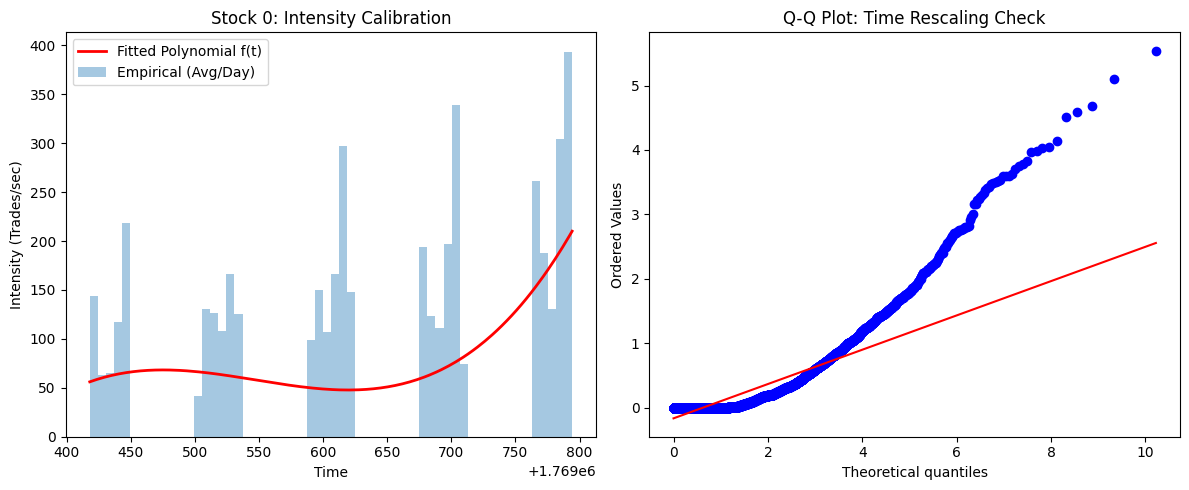

Stock 0 - KS Test p-value: 0.0000e+00
Expected # trades/day: 28797.7
Observed # trades (day 0): 19076
Result: Model may not fully capture dynamics (reject H0)



C:\Users\adoni\AppData\Local\Temp\ipykernel_29904\3235676020.py:6: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(bin_centers, counts, deg=5)


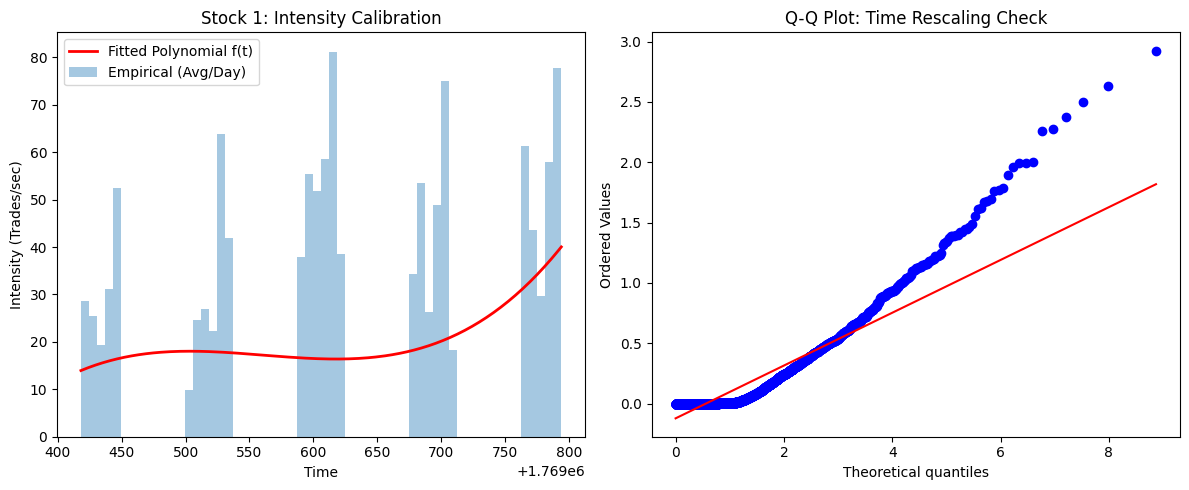

Stock 1 - KS Test p-value: 0.0000e+00
Expected # trades/day: 7505.3
Observed # trades (day 0): 4927
Result: Model may not fully capture dynamics (reject H0)



C:\Users\adoni\AppData\Local\Temp\ipykernel_29904\3235676020.py:6: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(bin_centers, counts, deg=5)


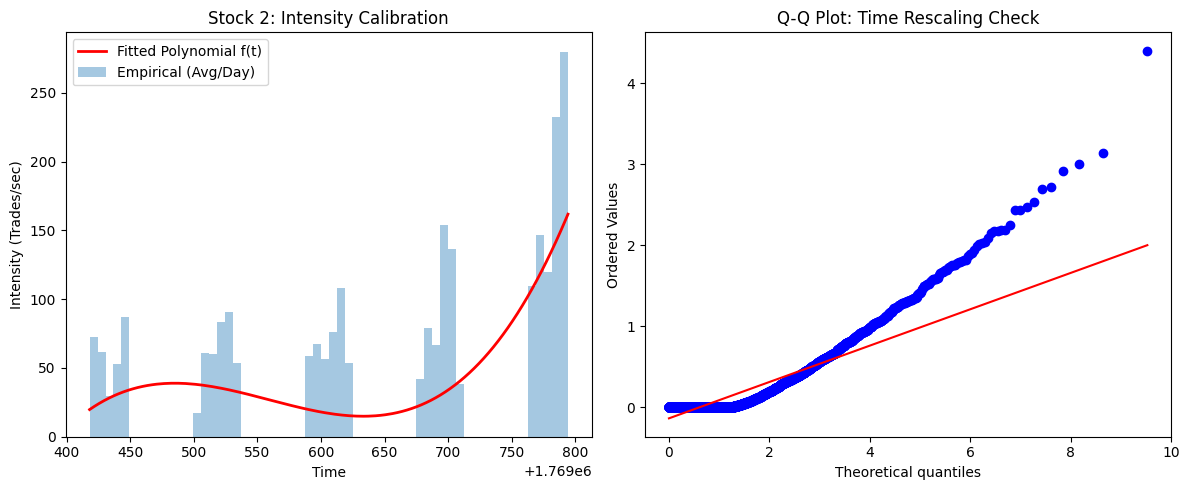

Stock 2 - KS Test p-value: 0.0000e+00
Expected # trades/day: 15650.0
Observed # trades (day 0): 9500
Result: Model may not fully capture dynamics (reject H0)



In [8]:
stocks = trades_df['stock'].unique()
n_days = trades_df['day'].nunique()

trades_df['ts'] = pd.to_datetime(trades_df['ts'], unit='s').astype(np.int64) / 1e9
T_start = trades_df['ts'].min()
T_end = trades_df['ts'].max()
T_duration = T_end - T_start

for stock_id in stocks:
    stock_data = trades_df[trades_df['stock'] == stock_id]
    all_tss = stock_data['ts'].values

    fitted_intensity, bin_centers, empirical_intensity = fit_intensity(all_tss, (T_start, T_end), bins=60)
    
    def f_t(t):
        """Intensity function for absolute timestamps"""
        return fitted_intensity(t) / n_days
    
    def f_t_relative(t):
        """Intensity function for relative time [0, T_duration]"""
        return f_t(t + T_start)

    lambda_star = max([f_t(t) for t in np.linspace(T_start, T_end, 100)]) * 1.2
    simulated_trades_relative = thinning_algorithm(T_duration, f_t_relative, lambda_star)
    simulated_trades = simulated_trades_relative + T_start
    
    t_grid = np.linspace(T_start, T_end, 200)
    lambda_vals = [f_t(t) for t in t_grid]
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.bar(bin_centers, empirical_intensity/n_days, width=(T_end-T_start)/60, alpha=0.4, label='Empirical (Avg/Day)')
    plt.plot(t_grid, lambda_vals, 'r-', lw=2, label='Fitted Polynomial f(t)')
    plt.title(f'Stock {stock_id}: Intensity Calibration')
    plt.xlabel('Time')
    plt.ylabel('Intensity (Trades/sec)')
    plt.legend()
    
    # Goodness-of-Fit
    day0_tss = np.sort(stock_data[stock_data['day'] == 0]['ts'].values)
    lambda_grid = np.array([f_t(t) for t in t_grid])
    Lambda_grid = np.cumsum(lambda_grid) * (t_grid[1] - t_grid[0])
    transformed_tss = np.interp(day0_tss, t_grid, Lambda_grid)

    tau_diffs = np.diff(transformed_tss)
    
    plt.subplot(1, 2, 2)
    stats.probplot(tau_diffs, dist="expon", plot=plt)
    plt.title('Q-Q Plot: Time Rescaling Check')
    
    plt.tight_layout()
    plt.show()

    ks_stat, p_value = stats.kstest(tau_diffs, 'expon')
    print(f"Stock {stock_id} - KS Test p-value: {p_value:.4e}")
    print(f"Expected # trades/day: {np.trapezoid(lambda_vals, t_grid):.1f}")
    print(f"Observed # trades (day 0): {len(day0_tss)}")
    if p_value > 0.05:
        print("Result: Model provides a reasonable fit (fail to reject H0)")
    else:
        print("Result: Model may not fully capture dynamics (reject H0)")
    print()

---
## 2. Brownian motions with Poisson sampling

In [9]:
def simulate_covariance(taus):
    T = 3600 * 6.5
    dt_fine = 0.1
    n_steps = int(T / dt_fine)
    
    sigma1 = 0.01 / np.sqrt(T)
    sigma2 = 0.02 / np.sqrt(T)
    rho = 0.5
    mu1 = 0.1
    mu2 = 0.2
    
    Z1 = np.random.normal(0, np.sqrt(dt_fine), n_steps)
    Z2 = np.random.normal(0, np.sqrt(dt_fine), n_steps)
    dW1 = Z1
    dW2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2
    
    p1_true = np.concatenate(([0], np.cumsum(sigma1 * dW1)))
    p2_true = np.concatenate(([0], np.cumsum(sigma2 * dW2)))
    time_true = np.linspace(0, T, n_steps + 1)
    
    def get_trade_times(mu, T_max):
        """Simulate Poisson process with intensity mu"""
        t = 0
        times = [0.0]
        while t < T_max:
            t += np.random.exponential(1/mu)
            if t < T_max:
                times.append(t)
        return np.array(times)
    
    t1_obs = get_trade_times(mu1, T)
    t2_obs = get_trade_times(mu2, T)
    
    idx1 = np.searchsorted(time_true, t1_obs) - 1
    idx2 = np.searchsorted(time_true, t2_obs) - 1
    p1_obs = p1_true[idx1]
    p2_obs = p2_true[idx2]
    
    covariances = []
    
    for tau in taus:
        grid = np.arange(0, T + 0.001, tau)
        idx_grid1 = np.searchsorted(t1_obs, grid, side='right') - 1
        idx_grid2 = np.searchsorted(t2_obs, grid, side='right') - 1
        idx_grid1 = np.maximum(idx_grid1, 0)
        idx_grid2 = np.maximum(idx_grid2, 0)
        
        p1_resampled = p1_obs[idx_grid1]
        p2_resampled = p2_obs[idx_grid2]
        r1 = np.diff(p1_resampled)
        r2 = np.diff(p2_resampled)
        rc = np.sum(r1 * r2)
        covariances.append(rc)
    
    true_cov = rho * sigma1 * sigma2 * T
    
    return taus, covariances, true_cov

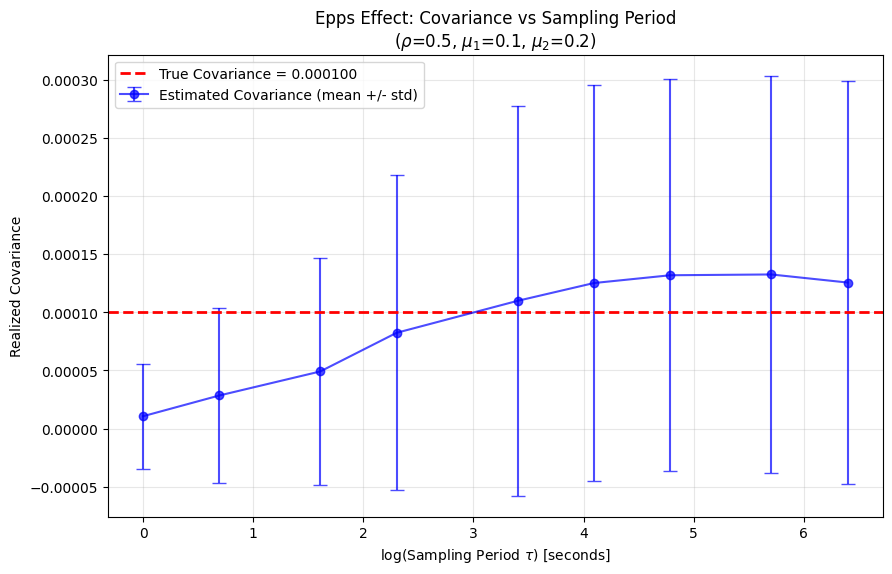

True covariance: 0.000100

Bias at different sampling frequencies:
τ =    1s: Estimated = 0.000011, Bias =  -89.4%
τ =    2s: Estimated = 0.000028, Bias =  -71.5%
τ =    5s: Estimated = 0.000049, Bias =  -50.9%
τ =   10s: Estimated = 0.000082, Bias =  -17.6%
τ =   30s: Estimated = 0.000110, Bias =   +9.9%
τ =   60s: Estimated = 0.000125, Bias =  +25.2%
τ =  120s: Estimated = 0.000132, Bias =  +31.9%
τ =  300s: Estimated = 0.000133, Bias =  +32.6%
τ =  600s: Estimated = 0.000126, Bias =  +25.6%


In [10]:
n_simulations = 100
all_covs = []
taus_out = None
true_target = 0

taus = [1, 2, 5, 10, 30, 60, 120, 300, 600]

for i in range(n_simulations):
    t_out, c_out, target = simulate_covariance(taus)
    all_covs.append(c_out)
    if i == 0:
        taus_out = t_out
        true_target = target

mean_covs = np.mean(all_covs, axis=0)
std_covs = np.std(all_covs, axis=0)

plt.figure(figsize=(10, 6))
plt.errorbar(np.log(taus_out), mean_covs, yerr=std_covs, fmt='b-o', capsize=5, alpha=0.7, label='Estimated Covariance (mean +/- std)')
plt.axhline(y=true_target, color='r', linestyle='--', linewidth=2, label=f'True Covariance = {true_target:.6f}')
plt.title(f'Epps Effect: Covariance vs Sampling Period\n($\\rho$={0.5}, $\\mu_1$={0.1}, $\\mu_2$={0.2})')
plt.xlabel('log(Sampling Period $\\tau$) [seconds]')
plt.ylabel('Realized Covariance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"True covariance: {true_target:.6f}")
print(f"\nBias at different sampling frequencies:")
for tau, mean_cov in zip(taus_out, mean_covs):
    bias = mean_cov - true_target
    rel_bias = 100 * bias / true_target
    print(f"\u03C4 = {tau:4.0f}s: Estimated = {mean_cov:.6f}, Bias = {rel_bias:+6.1f}%")

For small values of $\tau$ (high frequencies), the estimated covariance is much lower than the true covariance. This is due to the fact that at very high frequencies, the two processes are not observed simultaneously, leading to a significant underestimation of covariance. One asset may trade while the other does not, resulting in zero returns for one asset and non-zero returns for the other, which reduces the covariance estimate.

As $\tau$ increases, the estimator converges to the true covariance. Both assets are likely to have traded multiple times within the sampling period, allowing for a more accurate estimation of covariance.

We get a bias-variance trade-off: smaller $\tau$ leads to higher bias (underestimation) but lower variance, while larger $\tau$ reduces bias but increases variance.

---
## 3. Empirical intensities and LOB features

### 3.1 Rescaled observed queue size

In [11]:
def calculate_empirical_intensity(trades_df, lob_df, feature_type='spread', n_bins=20):
    """
    Calculate empirical trade intensity as a function of a LOB feature.
    
    Args:
        trades_df: DataFrame with trade data.
        lob_df: DataFrame with LOB updates.
        feature_type: 'spread' or 'queue_size'.
        n_bins: Number of bins for binning continuous features.
    
    Returns:
        x_values: Feature values
        intensities: Trade intensity λ(x) for each feature value
    """
    lob_local = lob_df.copy()
    trades_local = trades_df.copy()
    
    if not pd.api.types.is_numeric_dtype(lob_local['ts']):
        lob_local['ts'] = pd.to_numeric(lob_local['ts'])
    if not pd.api.types.is_numeric_dtype(trades_local['ts']):
        trades_local['ts'] = pd.to_numeric(trades_local['ts'])
    
    lob_local = lob_local.sort_values('ts').drop_duplicates(subset='ts', keep='last')
    
    side_col = None
    for possible_col in ['active_side', 'side', 'direction', 'aggressor']:
        if possible_col in trades_local.columns:
            side_col = possible_col
            break
    
    all_times = np.union1d(lob_local['ts'].values, trades_local['ts'].values)
    lob_indexed = lob_local.set_index('ts').sort_index()
    lob_expanded = lob_indexed.reindex(all_times, method='ffill').dropna()
    
    time_deltas = np.diff(lob_expanded.index.values)
    durations = np.append(time_deltas, 0)
    lob_expanded['duration'] = durations
    
    if side_col is not None:
        trade_counts = trades_local.groupby(['ts', side_col]).size().unstack(fill_value=0)
        trade_counts = trade_counts.reindex(lob_expanded.index, fill_value=0)
        
        buy_trades = np.zeros(len(lob_expanded))
        sell_trades = np.zeros(len(lob_expanded))
        
        for col in trade_counts.columns:
            col_lower = str(col).lower()
            if col == 1 or col_lower in ['buy', 'b', 'bid']:
                buy_trades = trade_counts[col].values
            elif col == -1 or col_lower in ['sell', 's', 'ask']:
                sell_trades = trade_counts[col].values
        
        lob_expanded['buy_trades'] = buy_trades
        lob_expanded['sell_trades'] = sell_trades
    else:
        trade_counts = trades_local.groupby('ts').size()
        trade_counts = trade_counts.reindex(lob_expanded.index, fill_value=0)
        lob_expanded['buy_trades'] = trade_counts.values / 2
        lob_expanded['sell_trades'] = trade_counts.values / 2
    
    if feature_type == 'spread':
        lob_expanded['spread'] = lob_expanded['ap'] - lob_expanded['bp']
        valid_data = lob_expanded[lob_expanded['spread'] > 0].copy()
        
        grouped = valid_data.groupby('spread').agg({
            'duration': 'sum',
            'buy_trades': 'sum',
            'sell_trades': 'sum'
        })
        
        grouped['total_trades'] = grouped['buy_trades'] + grouped['sell_trades']
        grouped = grouped[grouped['duration'] > 0]
        grouped['intensity'] = grouped['total_trades'] / grouped['duration']
        
        return grouped.index.values, grouped['intensity'].values
    
    elif feature_type == 'queue_size':
        avg_bid_vol = lob_expanded['bq'].mean()
        avg_ask_vol = lob_expanded['aq'].mean()
        
        sells_df = pd.DataFrame({
            'rescaled_vol': lob_expanded['bq'] / avg_bid_vol,
            'trades': lob_expanded['sell_trades'],
            'duration': lob_expanded['duration']
        })
        
        buys_df = pd.DataFrame({
            'rescaled_vol': lob_expanded['aq'] / avg_ask_vol,
            'trades': lob_expanded['buy_trades'],
            'duration': lob_expanded['duration']
        })
        
        combined = pd.concat([sells_df, buys_df], ignore_index=True)
        combined = combined.replace([np.inf, -np.inf], np.nan).dropna()
        combined['vol_bin'] = pd.qcut(combined['rescaled_vol'], q=n_bins, duplicates='drop')
        
        grouped = combined.groupby('vol_bin', observed=True).agg({
            'duration': 'sum',
            'trades': 'sum'
        })
        
        grouped = grouped[grouped['duration'] > 0]
        grouped['vol_center'] = grouped.index.map(lambda x: x.mid)
        grouped['intensity'] = grouped['trades'] / grouped['duration']
        
        return grouped['vol_center'].values, grouped['intensity'].values

### Analysis


Stock 0
Total trades: 143963
Total LOB updates: 1917800


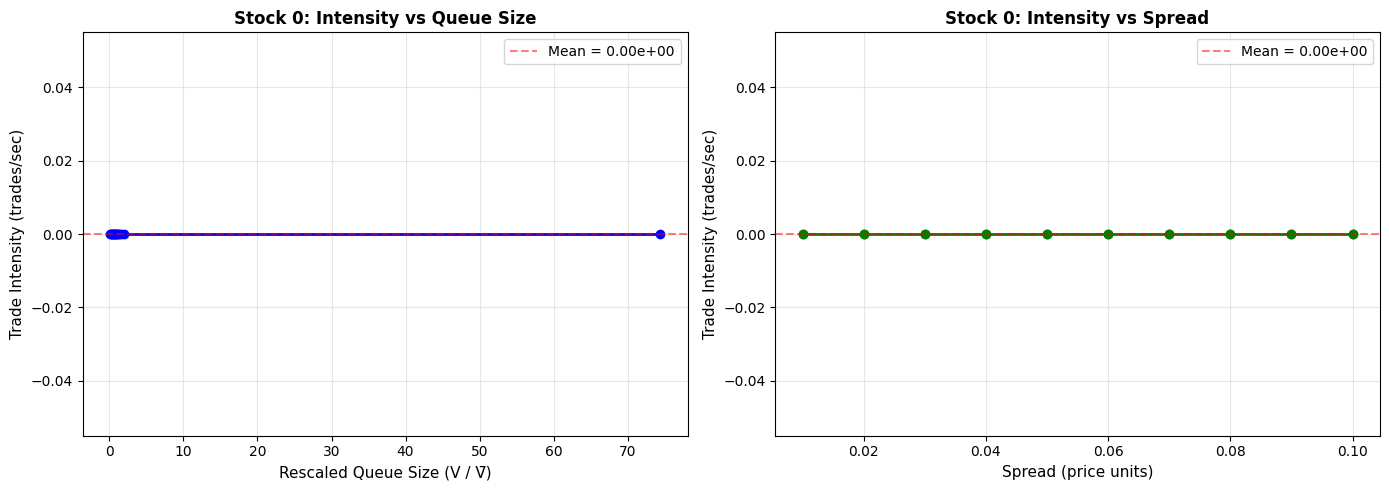


Queue Size Analysis:
Min rescaled volume: 0.09
Max rescaled volume: 74.37
Intensity range: [0.00e+00, 0.00e+00] trades/sec

Spread Analysis:
Observed spreads: 20 unique values
Min spread: 0.0100
Max spread: 0.1000
Intensity range: [0.00e+00, 0.00e+00] trades/sec

Stock 1
Total trades: 37522
Total LOB updates: 758551


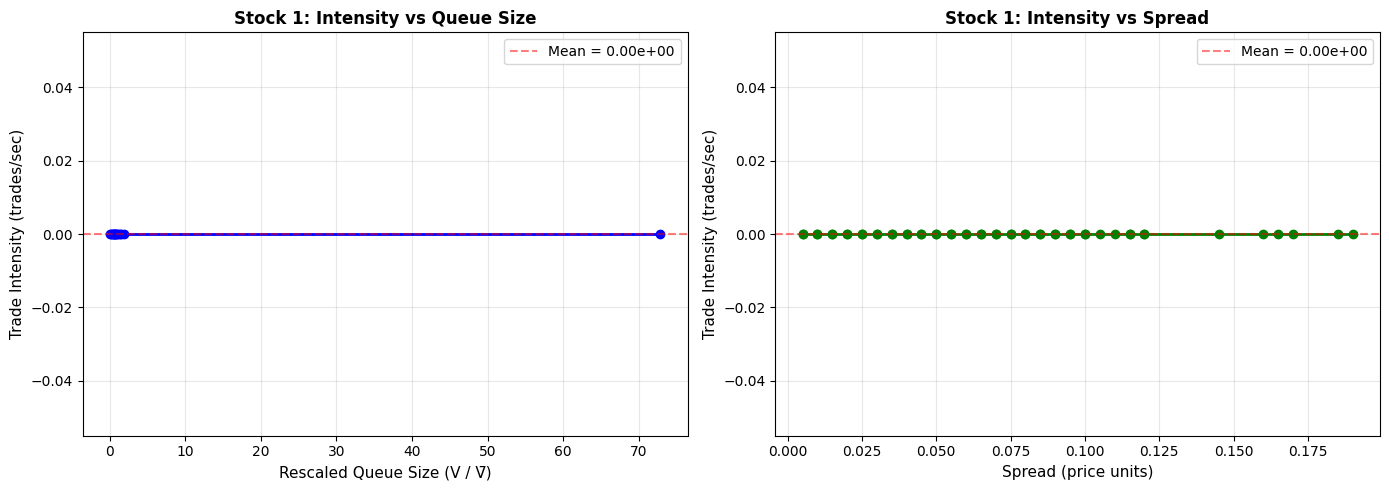


Queue Size Analysis:
Min rescaled volume: 0.06
Max rescaled volume: 72.80
Intensity range: [0.00e+00, 0.00e+00] trades/sec

Spread Analysis:
Observed spreads: 52 unique values
Min spread: 0.0050
Max spread: 0.1900
Intensity range: [0.00e+00, 0.00e+00] trades/sec

Stock 2
Total trades: 78209
Total LOB updates: 2028700


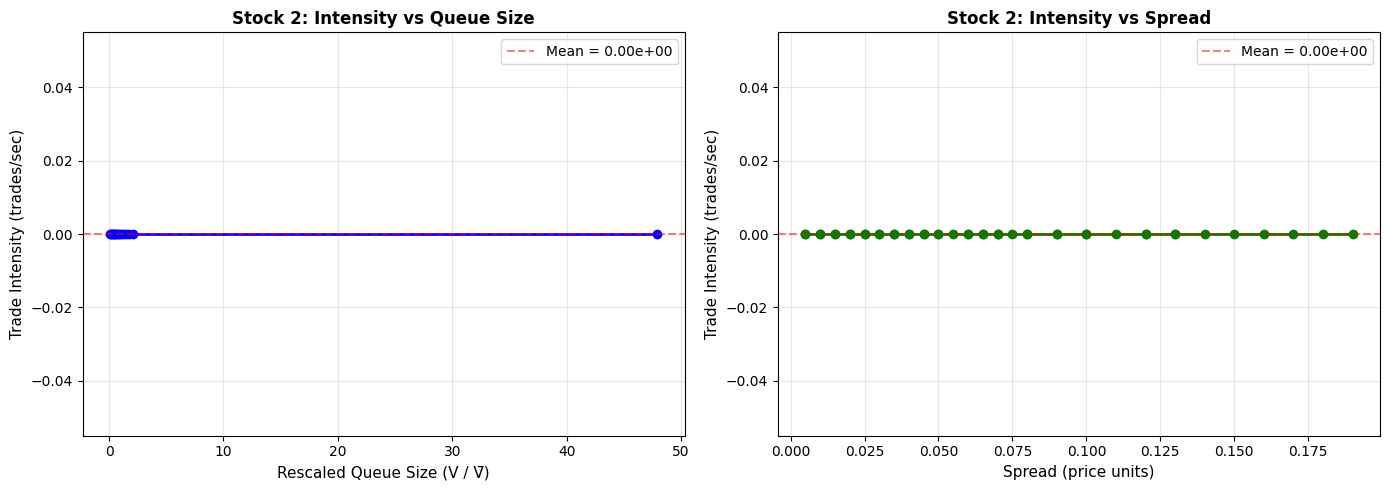


Queue Size Analysis:
Min rescaled volume: 0.07
Max rescaled volume: 47.91
Intensity range: [0.00e+00, 0.00e+00] trades/sec

Spread Analysis:
Observed spreads: 45 unique values
Min spread: 0.0050
Max spread: 0.1900
Intensity range: [0.00e+00, 0.00e+00] trades/sec


In [12]:
trades_analysis = trades_df.copy()
updates_analysis = updates_df.copy()

if not pd.api.types.is_numeric_dtype(trades_analysis['ts']):
    trades_analysis['ts'] = pd.to_datetime(trades_analysis['ts'], unit='s').astype(np.int64)
if not pd.api.types.is_numeric_dtype(updates_analysis['ts']):
    updates_analysis['ts'] = pd.to_datetime(updates_analysis['ts'], unit='s').astype(np.int64)

stocks = sorted(trades_analysis['stock'].unique())

for stock_id in stocks:
    stock_trades = trades_analysis[trades_analysis['stock'] == stock_id]
    stock_lob = updates_analysis[updates_analysis['stock'] == stock_id]
    
    print(f"\n{'='*60}")
    print(f"Stock {stock_id}")
    print(f"{'='*60}")
    print(f"Total trades: {len(stock_trades)}")
    print(f"Total LOB updates: {len(stock_lob)}")
    
    x_vol, y_vol_int = calculate_empirical_intensity(stock_trades, stock_lob, 'queue_size', n_bins=15)
    x_spr, y_spr_int = calculate_empirical_intensity(stock_trades, stock_lob, 'spread')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(x_vol, y_vol_int * 1e9, 'b-o', linewidth=2, markersize=6)
    axes[0].set_xlabel('Rescaled Queue Size (V / V̄)', fontsize=11)
    axes[0].set_ylabel('Trade Intensity (trades/sec)', fontsize=11)
    axes[0].set_title(f'Stock {stock_id}: Intensity vs Queue Size', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=np.mean(y_vol_int * 1e9), color='r', linestyle='--', 
                    alpha=0.5, label=f'Mean = {np.mean(y_vol_int * 1e9):.2e}')
    axes[0].legend()
    
    axes[1].plot(x_spr, y_spr_int * 1e9, 'g-o', linewidth=2, markersize=6)
    axes[1].set_xlabel('Spread (price units)', fontsize=11)
    axes[1].set_ylabel('Trade Intensity (trades/sec)', fontsize=11)
    axes[1].set_title(f'Stock {stock_id}: Intensity vs Spread', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=np.mean(y_spr_int * 1e9), color='r', linestyle='--', 
                    alpha=0.5, label=f'Mean = {np.mean(y_spr_int * 1e9):.2e}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nQueue Size Analysis:")
    print(f"Min rescaled volume: {x_vol.min():.2f}")
    print(f"Max rescaled volume: {x_vol.max():.2f}")
    print(f"Intensity range: [{y_vol_int.min()*1e9:.2e}, {y_vol_int.max()*1e9:.2e}] trades/sec")
    
    print(f"\nSpread Analysis:")
    print(f"Observed spreads: {len(x_spr)} unique values")
    print(f"Min spread: {x_spr.min():.4f}")
    print(f"Max spread: {x_spr.max():.4f}")
    print(f"Intensity range: [{y_spr_int.min()*1e9:.2e}, {y_spr_int.max()*1e9:.2e}] trades/sec")

### Interpretation

**Queue Size:** Lower queue sizes typically show higher trade intensity as traders rush to execute before liquidity depletes. This aligns with adverse selection and inventory risk theories.

**Spread:** Tighter spreads encourage more trading due to lower transaction costs. Wider spreads deter execution and signal higher adverse selection risk.